# 3. Tutorial 3

**Course:** Power Electronics Devices and Components  

## 3.1. Gate-drive resistance, Miller charge, and switching loss

MOSFET switching study with the simplified gate-charge model.

Following parameters are given:
- $V_\mathrm{DC} = 100~\mathrm{V}$
- $I_\mathrm{D} = 20~\mathrm{A}$
- $V_\mathrm{drv} = 12~\mathrm{V}$
- $V_\mathrm{GP} = 6~\mathrm{V}$
- $Q_\mathrm{GS1} = 8~\mathrm{nC}$


Following parameter range shall be used:
- $Q_\mathrm{GD} \in \left\{ 10~\mathrm{nC}, 25~\mathrm{nC}, 40~\mathrm{nC} \right\}$
- $R_\mathrm{g} \in \left\{ 5~\mathrm{\Omega}, 10~\mathrm{\Omega}, 20~\mathrm{\Omega} \right\}$

3.1.1 Import necessary modules (numpy as np and matplotlib.pyplot as plt) and add constant variables for the constant values.

3.1.2 Create a function with input parameter $R_\mathrm{g}$, which calculates the gate current $I_\mathrm{g}$ according
$$I_\mathrm{g} = \frac{V_\mathrm{drv} - V_\mathrm{GP}}{R_\mathrm{g}}.$$

3.1.3 Create a function with input parameter $I_\mathrm{g}$, which calculates the $t_\mathrm{M}$ according
$$t_\mathrm{M} = \frac{Q_\mathrm{GD}}{I_\mathrm{g}}.$$

3.1.4 Create a function with input parameter  $t_\mathrm{M}$, which calculates the energy loss $E_\mathrm{sw}$ according
$$E_\mathrm{sw} \approx \frac{1}{6} V_\mathrm{DC} I_\mathrm{D} t_\mathrm{M}.$$

3.1.5 Plot $t_\mathrm{M}$ versus $R_\mathrm{g}$ for each value of $Q_\mathrm{GD}$ within the given range.

3.1.6 Plot $E_\mathrm{sw}$ versus $R_\mathrm{g}$

3.1.7 Explain which parameter hurts switching speed more strongly in this simplified model.

3.1.8 Comment on the trade-off between fast switching and EMI.



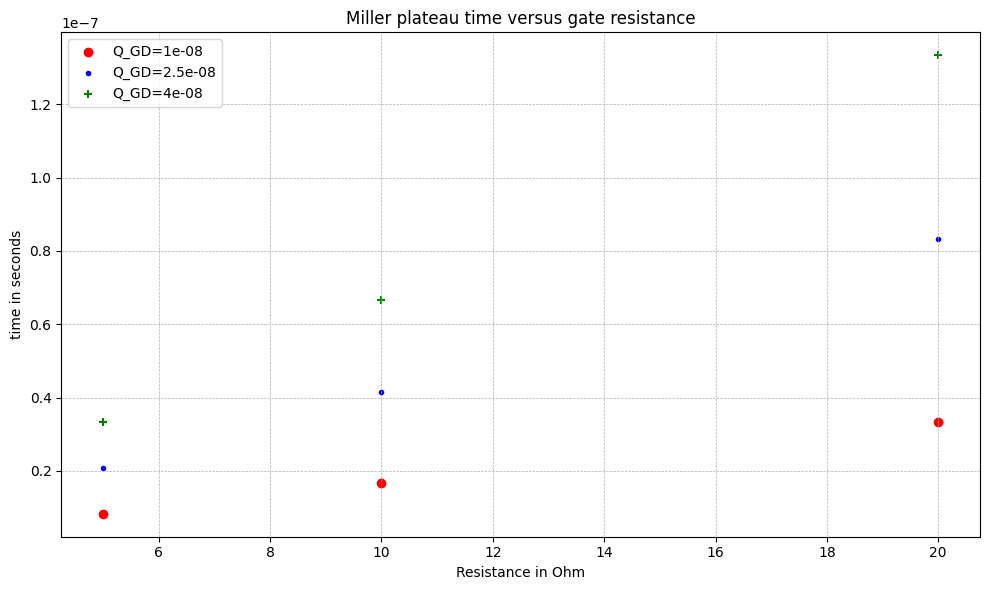

In [5]:
# Subtask 3.1.1 Import necessary modules (numpy as np and matplotlib.pyplot as plt) and add constant variables for the constant values.

import numpy as np
import matplotlib.pyplot as plt

# Create color list and marker list
color_list = ['red', 'blue', 'green', 'orange', 'black', 'cyan', 'magenta', 'purple']
marker_list=['o', '.', '+', '_', '*', 's', 'D', '^', 'v', '<', '>', 'p', 'h', 'H', 'x', 'D', 'd', 'P', 'X']


# ---------------------------------------------------------------------
# Fixed constants for the tutorial
# ---------------------------------------------------------------------
V_DC = 100      # 100V
I_D = 20        # 20A
V_drv = 12      # 12V
V_GP = 6        # 6V
Q_GS1 = 8e-9    # 8nC

Q_GD = [10e-9, 25e-9, 40e-9]        # Unit Couloumb
R_g  = np.array([5, 10, 20])        # Unit Ohm

# Subtask 3.1.2 Create a function with input parameter R_g, which calculates the gate current I_g according
def get_I_g(act_R_g):
    I_g = (V_drv - V_GP) / act_R_g
    return I_g

# Subtask 3.1.3 Create a function with input parameter I_g, which calculates the t_M according
def get_t_M(act_Q_GD, act_I_g):
    t_M = act_Q_GD / act_I_g
    return t_M

# Subtask 3.1.4 Create a function with input parameter t_M, which calculates the energy loss E_sw
def get_E_sw(act_t_M):
    E_sw = 1 / 6 *  V_DC * I_D * act_t_M
    return E_sw

if __name__ == "__main__":
    # Subtask 3.1.5 Plot t_M versus R_g for each value of Q_GD within the given range.

    # Generate the plot
    plt.figure(figsize=(10, 6))
    for i, act_Q_GD in enumerate(Q_GD):
        # Calculate gate current
        I_g = get_I_g(R_g)
        # Calculate Miller time
        t_M = get_t_M(act_Q_GD, I_g)
        # Create legend per result
        text=f"Q_GD={act_Q_GD}"
        plt.scatter(R_g, t_M, label=text, color=color_list[i], marker=marker_list[i])

    plt.xlabel(r'Resistance in Ohm')
    plt.ylabel('time in seconds')
    plt.title('Miller plateau time versus gate resistance')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
    

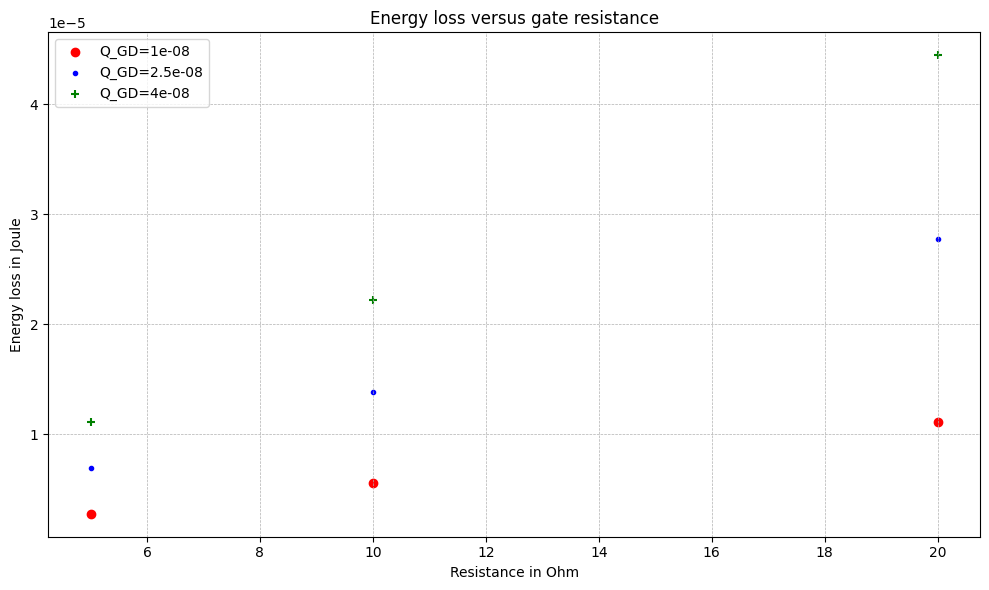

In [6]:
if __name__ == "__main__":
    # Subtask 3.1.6 Plot E_sw versus R_g
    # Generate the plot
    plt.figure(figsize=(10, 6))
    for i, act_Q_GD in enumerate(Q_GD):
        # Calculate gate current
        I_g = get_I_g(R_g)
        # Calculate Miller time
        t_M = get_t_M(act_Q_GD, I_g)
        # Calculate Energy loss
        E_sw = get_E_sw(t_M)
        # Create legend per result
        text=f"Q_GD={act_Q_GD}"
        plt.scatter(R_g, E_sw, label=text, color=color_list[i], marker=marker_list[i])

    plt.xlabel(r'Resistance in Ohm')
    plt.ylabel('Energy loss in Joule')
    plt.title('Energy loss versus gate resistance')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


### 3.1.7 Solution Explain which parameter hurts switching speed more strongly in this simplified model.

In this simplified model, both $R_\mathrm{g}$ and $Q_\mathrm{GD}$ influence switching speed linearly because
$$t_\mathrm{M} = \frac{Q_\mathrm{GD}}{I_\mathrm{g}} = \frac{Q_\mathrm{GD} R_\mathrm{g}}{V_\mathrm{drv}-V_\mathrm{GP}}.$$
So increasing either $R_\mathrm{g}$ or $Q_\mathrm{GD}$ by the same percentage increases $t_\mathrm{M}$ by the same percentage. Practically, large $Q_\mathrm{GD}$ is often harder to avoid because it is tied to MOSFET structure and voltage class.

### 3.1.8 Solution Comment on the trade-off between fast switching and EMI.

Lower $R_\mathrm{g}$ gives higher gate current, shorter $t_\mathrm{M}$, and lower switching energy. However, faster transitions increase $dV/dt$ and $dI/dt$, which raise EMI, ringing, and stress on layout/parasitics. Higher $R_\mathrm{g}$ reduces EMI but increases switching loss and device heating.


## 3.2 Low-voltage versus high-voltage MOSFET trade-off map

Create a loss map for three MOSFET families:
- $150~\mathrm{V}$ device: $R_\mathrm{DS(on)} = 4~\mathrm{m\Omega}$, $(t_\mathrm{r} + t_\mathrm{f}) = 35~\mathrm{ns}$
- $300~\mathrm{V}$ device: $R_\mathrm{DS(on)} = 20~\mathrm{m\Omega}$, $(t_\mathrm{r} + t_\mathrm{f}) = 70~\mathrm{ns}$
- $650~\mathrm{V}$ device: $R_\mathrm{DS(on)} = 120~\mathrm{m\Omega}$, $(t_\mathrm{r} + t_\mathrm{f}) = 120~\mathrm{ns}$

As parameter use:
- $V_\mathrm{DS} = 100 ~\mathrm{V}$
- duty ratio $D = 0.5$

and paramter range use:
- $I_\mathrm{D} = 10 \ldots 40 ~\mathrm{A}$
- $f_\mathrm{s} = 20 \ldots 300 ~\mathrm{kHz}$

3.2.1 Create a dictionary with Dev[voltage class]. To each voltage class key the a internal dictionary with keys 'R_DSon' and 't_r_f' is to assign with the correspondedn values.
E.g. access to a value is 'Devices["Dev150"]["R_DSon"]'.

3.2.2 Add constant variables for the constant values and define the parameter range  with 100 samples for current and 280 samples for switching frequency.

3.2.3 Create a function with input parameters  $I_\mathrm{D}$ to calculate $I_\mathrm{rms}$ based on equation $I_\mathrm{rms} = I_\mathrm{D}\sqrt{D}.$

3.2.4 Create a function with input parameter  $I_\mathrm{rms}$ and $R_\mathrm{DS(on)}$, which calculates the power consumption for on-state.

3.2.5 Create a function with input parameter $I_\mathrm{D}$ and $f_\mathrm{s}$, which calculates  switch power loss based on equation

$$P_\mathrm{sw} = \frac{1}{6} V_\mathrm{DS} I_\mathrm{D} (t_\mathrm{r} + t_\mathrm{f}) f_\mathrm{s}.$$

3.2.6 Plot total loss versus current at fixed frequency within the given frequency range for all devices.

3.2.7 Plot total loss versus frequency at fixed current within the given current range for all devices.

3.2.8 Determine the penalty of over-rating the voltage class.

3.2.9 Write a short design conclusion.



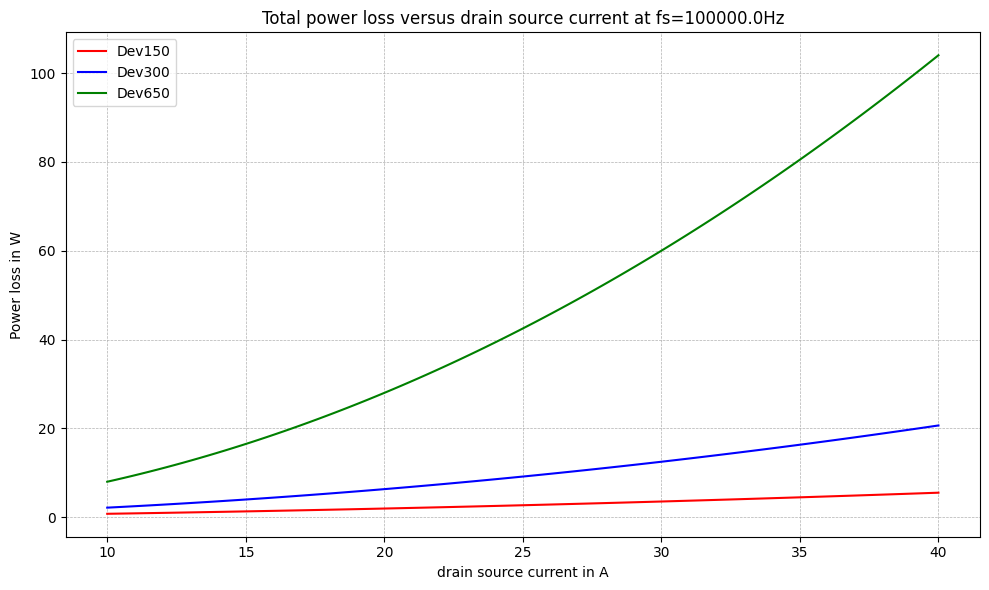

In [7]:
# ---------------------------------------------------------------------
# Fixed constants for the tutorial
# ---------------------------------------------------------------------
# Subtask 3.2.1 Create a dictionary with Dev[voltage class].
#               To each voltage class key the a internal dictionary with keys 'R_DSon' and 't_r_f' is to assign with the correspondedn value

# Create a loss map for three MOSFET families:
    
Devices = {
    'Dev150':  {'R_DSon': 4e-3, 't_r_f': 35e-9},
    'Dev300':  {'R_DSon': 20e-3, 't_r_f': 70e-9},
    'Dev650':  {'R_DSon': 120e-3, 't_r_f': 120e-9},
}

# Subtask3.2.2 Add constant variables for the constant values and define the parameter range  with 100 samples for current and 280 samples for switching frequency.

V_DS = 100                             # Unit in V
D = 0.5

# Create a linear space with 100 samples
I_D_range = np.linspace(10, 40, 100)        # Unit Ampere
# Create a linear space with 100 samples
f_s_range = np.linspace(20e3, 300e3, 280)   # Unit Hertz

# Subtask 3.2.3 Create a function with input parameters  I_D to calculate I_rms
def get_I_rms(act_I):
    I_rms = act_I * D**(0.5)
    return I_rms

# Subtask 3.2.4 Create a function with input parameter  $I_ms and R_DSon, which calculates the power consumption for on-state.
def get_P_closs(act_I, act_RSon):
    P_closs = (act_I**2) * act_RSon
    return P_closs

# Subtask 3.2.5 Create a function with input parameter I_D and f_s, which calculates  switch power loss based on equation
def get_P_sloss(act_I, act_t_r_f, act_f_s):
    P_sloss = 1/6 * V_DS * act_I * act_t_r_f * act_f_s
    return P_sloss


if __name__ == "__main__":
    # Subtask 3.2.6 Plot total loss versus current at one fixed frequency within the given frequency range for all devices.

    # Define fixed frequency (middle)
    fixed_frequency = 100e3
    plot_colors = ['red', 'blue', 'green']

    # Generate the plot
    plt.figure(figsize=(10, 6))
    # For-loop over devices
    for i, act_device_name in enumerate(Devices):
        act_device=Devices[act_device_name]
        # Calculate rms-current
        I_rms = get_I_rms(I_D_range)
        # Calculate conduction power loss
        P_closs = get_P_closs(I_rms, act_device["R_DSon"] )
        # Calculate switching power loss
        P_sloss = get_P_sloss(I_D_range, act_device["t_r_f"], fixed_frequency )
        # Calculate the total loss
        P_tot = P_closs + P_sloss 
        # Create legend per result
        text=act_device_name
        plt.plot(I_D_range, P_tot, label=text, color=plot_colors[i])
            

    plt.xlabel("drain source current in A")
    plt.ylabel("Power loss in W")
    plt.title(f"Total power loss versus drain source current at fs={fixed_frequency}Hz")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


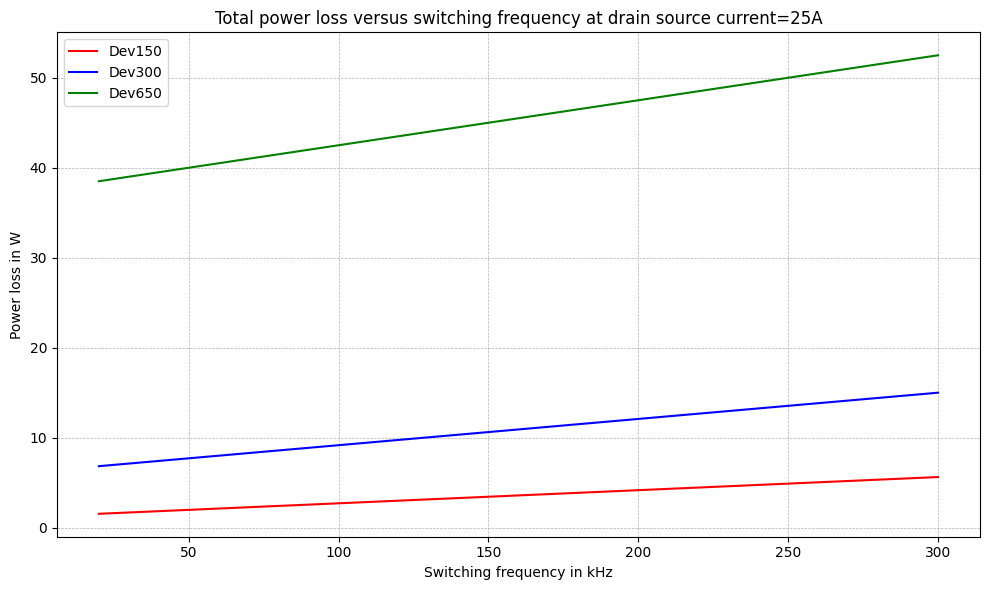

In [8]:
if __name__ == "__main__":
    # Subtask 3.2.7 Plot total loss versus frequency at fixed current within the given current range for all devices.

    # Define fixed current (middle)
    fixed_current = 25
    plot_colors = ['red', 'blue', 'green']

    # Calculate rms-current
    I_rms = get_I_rms(fixed_current)


    # Generate the plot
    plt.figure(figsize=(10, 6))
    # For-loop over devices
    for i, act_device_name in enumerate(Devices):
        act_device=Devices[act_device_name]
        # Calculate conduction power loss
        P_closs = get_P_closs(I_rms, act_device["R_DSon"] )
        # Calculate switching power loss
        P_sloss = get_P_sloss(fixed_current, act_device["t_r_f"], f_s_range )
        # Calculate the total loss
        P_tot = P_closs + P_sloss 
        # Create legend per result
        text=act_device_name
        plt.plot(f_s_range/1000, P_tot, label=text, color=plot_colors[i])
            

    plt.xlabel("Switching frequency in kHz")
    plt.ylabel("Power loss in W")
    plt.title(f"Total power loss versus switching frequency at drain source current={fixed_current}A")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3.2.8 Solution Determine the penalty of over-rating the voltage class.

At the same operating point ($V_\mathrm{DS}=100$ V), moving from 150 V to 300 V and 650 V class devices increases both $R_\mathrm{DS(on)}$ and $(t_\mathrm{r}+t_\mathrm{f})$. Therefore both conduction loss and switching loss rise. The 650 V class shows the largest penalty, especially at high current and high frequency.

### 3.2.9 Solution Write a short design conclusion.

For this 100 V application, the 150 V device is generally the best efficiency choice across the examined current and frequency range. Over-rating the voltage class reduces efficiency and increases thermal burden unless extra voltage margin is required by transients or reliability constraints.

Correction note: switching-loss terms were corrected to use $I_\mathrm{D}$ (as defined by the equation), so these conclusions now match the intended model. 